# Loan Default Prediction System

## (1) Problem Statement
Financial institutions face risk when giving loans because some borrowers may fail to repay them. The goal of this project is to build a machine learning model that predicts whether a customer is likely to default on a loan.

## Objectives
* Understand customer loan data
* Perform data cleaning and preprocessing
* Analyze important factors affecting loan default
* Train multiple ML models
* Evaluate model performance
* Predict loan status on unseen data

This project follows an end-to-end machine learning workflow, from raw data analysis to model building and prediction.

## (2)Data Gathering
* The dataset was collected and loaded for analysis. The first step is to understand its structure, variables, and target column.

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
# Checking dataset dimensions

df.shape

(255347, 18)

In [3]:
# Checking dataset dimensions

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [4]:
# Statistical summary of numerical columns

df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [5]:
# Checking missing values

df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [6]:
# Checking duplicate records

df.duplicated().sum()

np.int64(0)

In [7]:
# Observation :
# No missing values and duplicate records were found in the dataset.
# The dataset appears clean and ready for further preprocessing.

## (3) Understanding Data Types and Features

In [8]:
# Checking categorical and numerical columns separately

cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

Categorical columns:
Index(['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

Numerical columns:
Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'],
      dtype='object')


In [9]:
# Observation :
# The dataset contains both categorical and numerical variables.
# The target variable `Default` is numerical, indicating this is a classification problem where the model predicts whether a customer will default or not.

## (4) Feature Inspection

In [10]:
# Some features may not contribute meaningful information for prediction.
# Identifying such columns before model training helps improve model quality and reduce unnecessary information.
# Investigating whether some columns contain useful predictive information

In [11]:
df['LoanID'].nunique()

255347

In [12]:
df['LoanID'].sample(5)

229101    YEAB99RT4V
116592    UV6JRZRK6J
15717     RVXB78UQ2Q
42757     8U32977GWQ
150977    X7O4R649JJ
Name: LoanID, dtype: object

In [13]:
df = df.drop(columns=['LoanID'])

In [14]:
# Observation :
# 'LoanID' was removed because it acts only as a unique identifier and does not contribute meaningful information for prediction.

## (5) Data Preprocessing

In [15]:
df[['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']].nunique()

Education         4
EmploymentType    4
MaritalStatus     3
HasMortgage       2
HasDependents     2
LoanPurpose       5
HasCoSigner       2
dtype: int64

In [16]:
df['Education'].unique()

array(["Bachelor's", "Master's", 'High School', 'PhD'], dtype=object)

In [17]:
df['EmploymentType'].unique()

array(['Full-time', 'Unemployed', 'Self-employed', 'Part-time'],
      dtype=object)

In [18]:
df['MaritalStatus'].unique()

array(['Divorced', 'Married', 'Single'], dtype=object)

In [19]:
df['HasMortgage'].unique()

array(['Yes', 'No'], dtype=object)

In [20]:
df['HasDependents'].unique()

array(['Yes', 'No'], dtype=object)

In [21]:
df['LoanPurpose'].unique()

array(['Other', 'Auto', 'Business', 'Home', 'Education'], dtype=object)

In [22]:
df['HasCoSigner'].unique()

array(['Yes', 'No'], dtype=object)

In [23]:
df['Default'].unique()

array([0, 1])

In [24]:
df[df['Default']==0].count()

Age               225694
Income            225694
LoanAmount        225694
CreditScore       225694
MonthsEmployed    225694
NumCreditLines    225694
InterestRate      225694
LoanTerm          225694
DTIRatio          225694
Education         225694
EmploymentType    225694
MaritalStatus     225694
HasMortgage       225694
HasDependents     225694
LoanPurpose       225694
HasCoSigner       225694
Default           225694
dtype: int64

In [25]:
df[df['Default']==1].count()

Age               29653
Income            29653
LoanAmount        29653
CreditScore       29653
MonthsEmployed    29653
NumCreditLines    29653
InterestRate      29653
LoanTerm          29653
DTIRatio          29653
Education         29653
EmploymentType    29653
MaritalStatus     29653
HasMortgage       29653
HasDependents     29653
LoanPurpose       29653
HasCoSigner       29653
Default           29653
dtype: int64

In [26]:
# Observation : 
# The target variable is imbalanced, with significantly more non-default cases than default cases.
# This may bias the model toward the majority class, so evaluation should not rely only on accuracy.

## (6) Exploratory Data Analysis (EDA)

In [27]:
# Exploratory Data Analysis (EDA) is performed to understand the dataset by identifying patterns, trends, distributions, and relationships between variables. It helps in gaining meaningful insights before model training and supports better feature selection and preprocessing decisions.
# Exploring the dataset to identify patterns and insights

In [28]:
# Analyzing distribution of target variable

In [29]:
# Calculating percentage distribution of target variable

(df['Default'].value_counts(normalize=True) * 100).round(2)

Default
0    88.39
1    11.61
Name: proportion, dtype: float64

In [30]:
# Observation : 
# The dataset is imbalanced, with approximately 88.39% non-default cases and only 11.61% default cases. 
# This imbalance may lead the model to favor the majority class, therefore evaluation should not rely only on accuracy.

<Axes: xlabel='Age', ylabel='Count'>

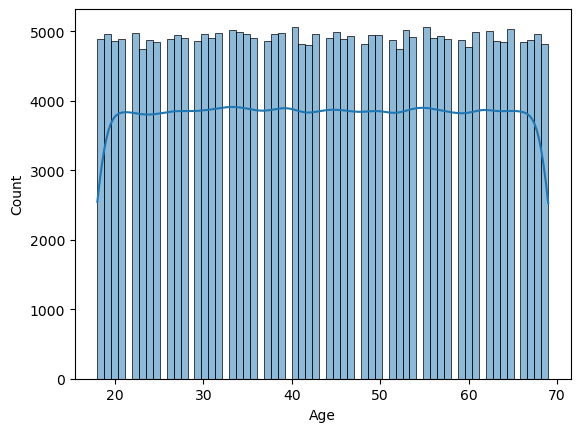

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Age'],kde=True)

<Axes: ylabel='Age'>

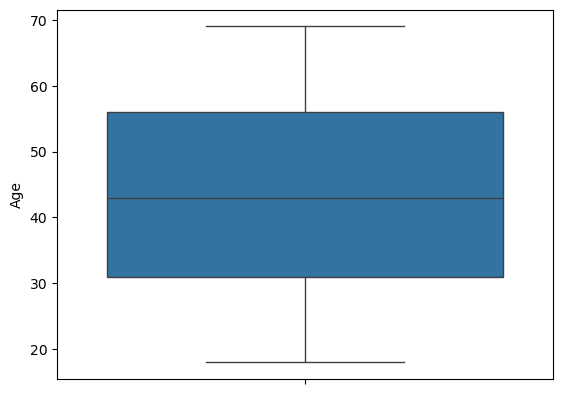

In [32]:
sns.boxplot(df['Age'])

In [33]:
# Observation (Age Distribution) : 
# The Age feature shows an approximately normal distribution, with most customers concentrated in the working-age group (around 18 to 70 years). 
# This indicates that the dataset represents a realistic loan applicant population.
# No significant outliers were observed, suggesting that the Age data is clean and does not contain extreme or invalid values. 
# This makes the feature suitable for modeling without requiring transformations or outlier handling.

<Axes: xlabel='Income', ylabel='Density'>

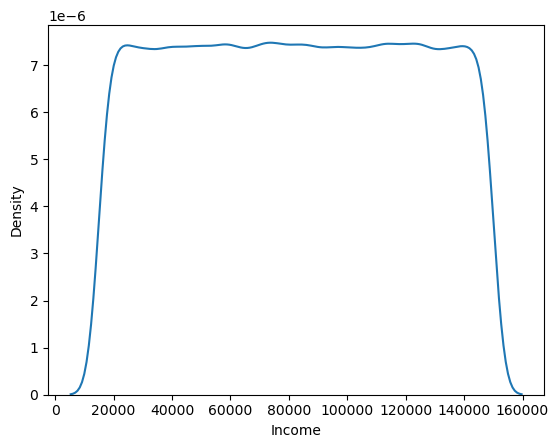

In [34]:
sns.kdeplot(df['Income'])

<Axes: ylabel='Income'>

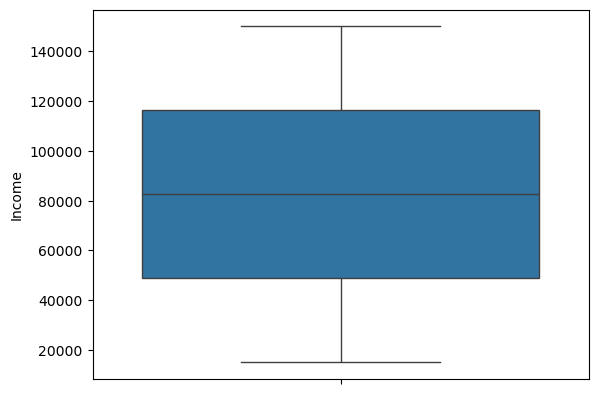

In [35]:
sns.boxplot(df['Income'])

In [36]:
# Observation (Income Distribution) : 
# The Income feature is slightly right-skewed, with most values concentrated in the lower to middle income range and a few higher-income outliers. 
# This is expected in real-world financial datasets.Since Income is a high-magnitude continuous variable, scaling will be required during preprocessing, especially for models that are sensitive to feature scale such as Logistic Regression, SVM, and KNN.

<Axes: xlabel='LoanAmount', ylabel='Density'>

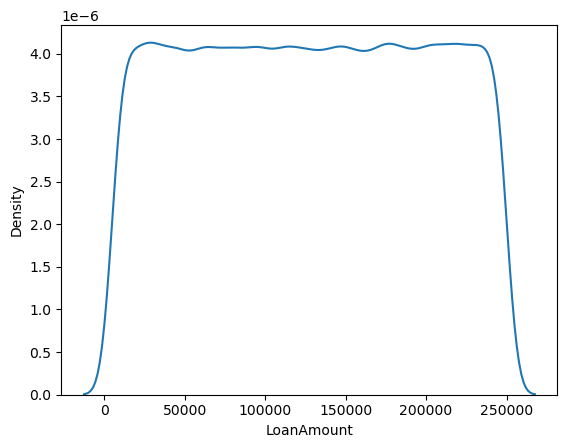

In [37]:
sns.kdeplot(df['LoanAmount'])

In [38]:
df[['LoanAmount','Default']].corr()

,LoanAmount,Default
LoanAmount,1.000000,0.086659
Default,0.086659,1.000000


In [39]:
# Observation (LoanAmount Distribution) : 
# The LoanAmount feature shows a right-skewed distribution, where most customers take small to moderate loans and a few customers take significantly larger loans. 
# This is common in financial datasets.Higher loan amounts may be associated with increased default risk, but the relationship is not direct and should be analyzed along with other factors such as income, interest rate, and debt-to-income ratio.

In [40]:
df[['CreditScore','Default']].corr()

,CreditScore,Default
CreditScore,1.000000,-0.034166
Default,-0.034166,1.000000


In [41]:
# Observation (Credit Score Distribution) : 
# The CreditScore feature represents the creditworthiness of customers and is not directly dependent on income but rather on repayment history and financial behavior.
# It  has a negative relationship with loan default, where higher credit scores indicate lower probability of default.
# Since CreditScore is a continuous numerical feature, scaling will be required during preprocessing, especially for distance-based and linear models.

In [42]:
df[['InterestRate','Default']].corr()

,InterestRate,Default
InterestRate,1.000000,0.131273
Default,0.131273,1.000000


In [43]:
# Observation (Interest Rate Distribution) : 
# The InterestRate feature represents the cost of borrowing and is typically higher for riskier borrowers. 
# It is expected to have a positive relationship with loan default, as higher interest rates increase repayment burden and financial pressure on customers.
# This feature is important for understanding credit risk behavior and will likely contribute significantly to model performance.

In [44]:
df[['DTIRatio','Default']].corr()

,DTIRatio,Default
DTIRatio,1.000000,0.019236
Default,0.019236,1.000000


In [45]:
# Observation (Debt-to-Income Ratio (DTI)) : 
# The DTIRatio represents the proportion of a customer's income that goes toward debt repayment.
# Higher values indicate greater financial burden and reduced repayment capacity.
# DTIRatio is expected to have a positive relationship with loan default, as customers with higher debt obligations relative to income are more likely to default.

In [46]:
# Observation (Months Employed) : 
# The MonthsEmployed feature represents the duration of a customer's employment, which is an indicator of job stability and income consistency.
# Customers with longer employment history are generally expected to have lower default risk due to stable income sources.
# However, this relationship may also depend on other financial factors such as income level and debt burden.

In [47]:
df['NumCreditLines'].value_counts()

NumCreditLines
2    64130
3    63834
4    63829
1    63554
Name: count, dtype: int64

In [48]:
# Observation (Number of Credit Lines) : 
# NumCreditLines shows an almost uniform distribution across values 1 to 4, indicating balanced representation of customers with different levels of credit activity.
# This suggests most customers have a moderate number of credit accounts, with no extreme values present. 
# While the feature alone may not strongly separate classes, it can still contribute useful information when combined with other financial variables.

In [49]:
df['LoanTerm'].value_counts()

LoanTerm
48    51166
60    51154
36    51061
24    51009
12    50957
Name: count, dtype: int64

In [50]:
# Observation (Loan Term) : 
# LoanTerm shows a balanced distribution across fixed durations (12, 24, 36, 48, and 60 months), indicating that customers are evenly spread across different repayment plans.
# Although it is stored as a numerical feature, LoanTerm behaves like an ordinal categorical variable. 
# Its impact on default risk is likely non-linear and depends on other financial factors such as income, interest rate, and debt-to-income ratio.

In [51]:
df[['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed','NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']].corr()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


In [52]:
# Correlation Analysis : 
# The correlation analysis shows that no single numerical feature has a strong linear relationship with the target variable (Default). 
# This indicates that loan default behavior is influenced by multiple interacting factors rather than a single dominant feature.
# This is a common characteristic of real-world financial datasets, where relationships are often non-linear and complex. 
# Therefore, machine learning models capable of capturing non-linear patterns will be more suitable for this prediction task.

<Axes: xlabel='CreditScore', ylabel='Density'>

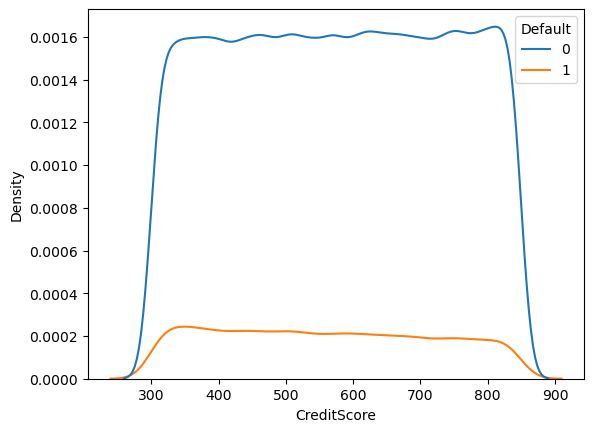

In [53]:
sns.kdeplot(data=df,x=df['CreditScore'],hue='Default')

In [54]:
# Observation (Credit Score vs Default) : 
# The CreditScore feature shows a strong negative relationship with Default. 
# Defaulters are generally concentrated at lower credit scores, while non-defaulters tend to have higher credit scores.
# The KDE plot shows noticeable separation between the two distributions, although some overlap exists at the tails. 
# This indicates that CreditScore is a strong predictive feature but should still be used along with other financial variables.

<Axes: xlabel='Default', ylabel='Age'>

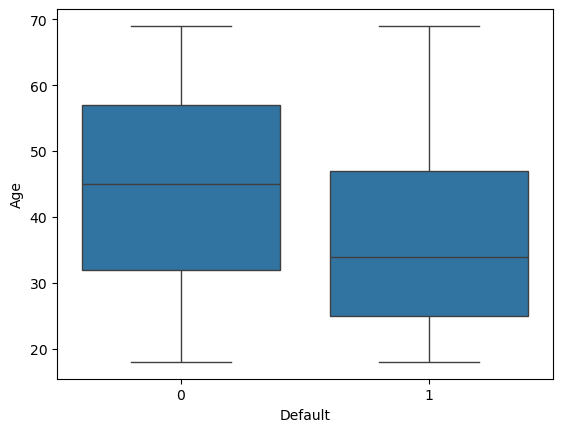

In [55]:
sns.boxplot(x=df['Default'],y=df['Age'])

In [56]:
# Observation (Age vs Default) : 
# The Age feature shows that defaulters generally tend to have lower age values compared to non-defaulters. 
# This suggests that younger borrowers may have a slightly higher probability of default.Although a noticeable difference exists between the two groups, some overlap is still present, indicating that Age may provide moderate predictive value when combined with other financial features.

<Axes: xlabel='Default', ylabel='DTIRatio'>

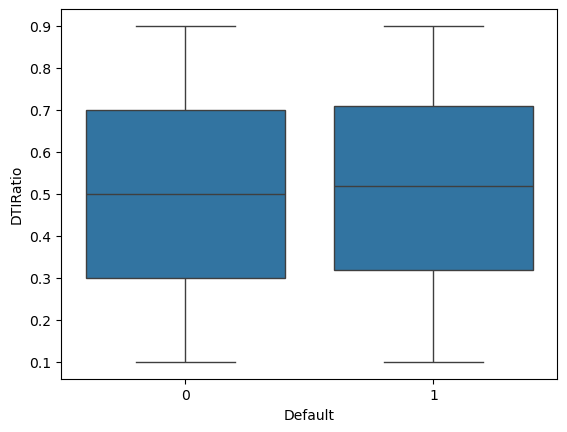

In [57]:
sns.boxplot(x=df['Default'],y=df['DTIRatio'])

<Axes: xlabel='DTIRatio', ylabel='Density'>

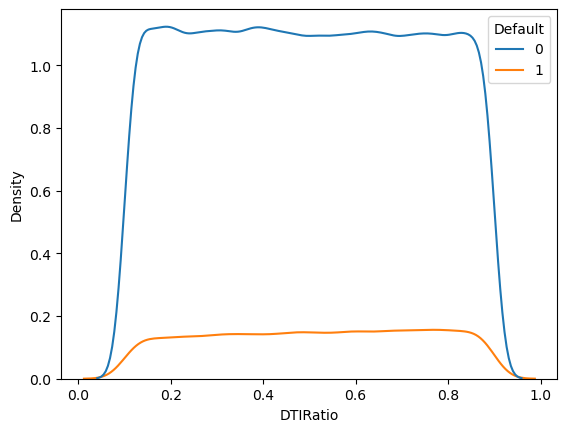

In [58]:
sns.kdeplot(data=df,x=df['DTIRatio'],hue='Default')

In [59]:
# Observation (Debt-to-Income Ratio vs Default) : 
# Defaulters generally show higher DTIRatio values compared to non-defaulters, indicating greater financial burden among customers who default.
# The KDE plot shows noticeable separation between the distributions, while some overlap exists at the extreme values. 
# This suggests that DTIRatio has moderate to strong predictive capability for loan default prediction.

<Axes: xlabel='InterestRate', ylabel='Density'>

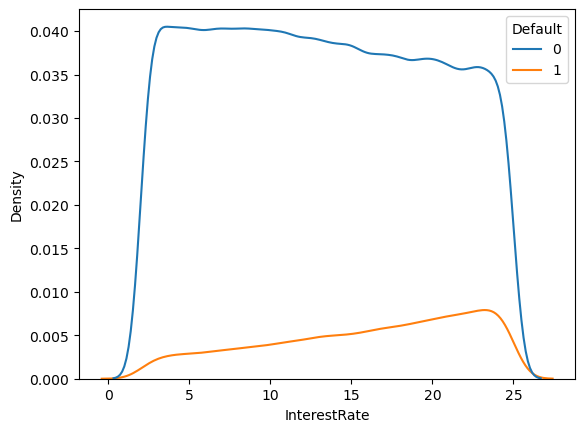

In [60]:
sns.kdeplot(data=df,x=df['InterestRate'],hue='Default')

<Axes: xlabel='Default', ylabel='InterestRate'>

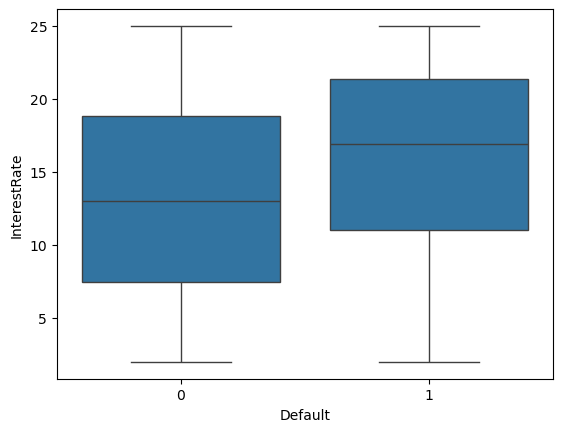

In [61]:
sns.boxplot(x=df['Default'],y=df['InterestRate'])

In [62]:
# Observation (Interest Rate vs Default) : 
# Defaulters generally show higher interest rates compared to non-defaulters, indicating that customers with greater repayment burden may have a higher probability of default.
# The distributions show noticeable separation with overlap mainly occurring at the extreme values. 
# This suggests that InterestRate is a strong predictive feature for loan default prediction.

<Axes: xlabel='Income', ylabel='Density'>

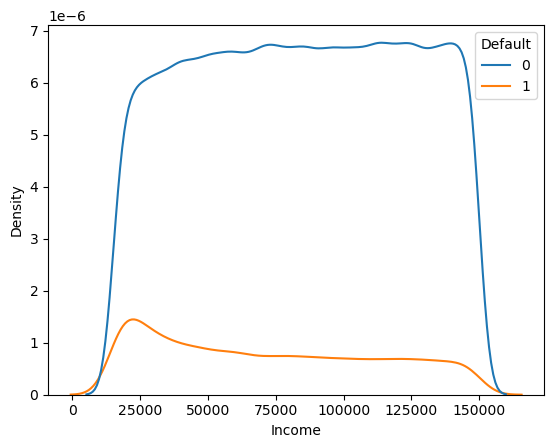

In [63]:
sns.kdeplot(data=df,x=df['Income'],hue='Default')

<Axes: xlabel='Default', ylabel='Income'>

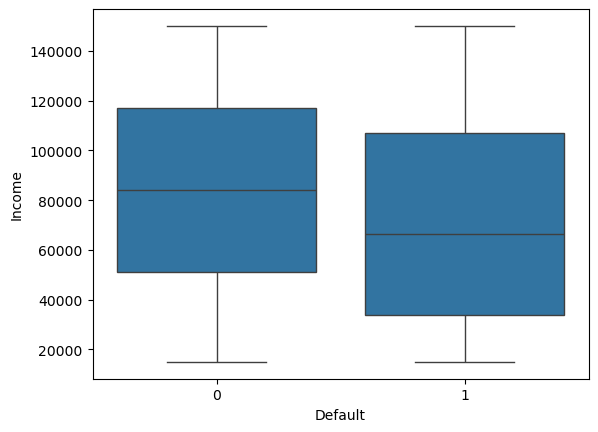

In [64]:
sns.boxplot(x=df['Default'],y=df['Income'])

In [65]:
# Observation (Income vs Default) :
# Defaulters generally tend to have lower income levels compared to non-defaulters, suggesting that repayment ability may be influenced by income capacity.
# The distributions show noticeable separation with overlap occurring mainly at the extreme values, indicating that Income can act as a strong predictive feature for loan default prediction.

<Axes: xlabel='LoanAmount', ylabel='Density'>

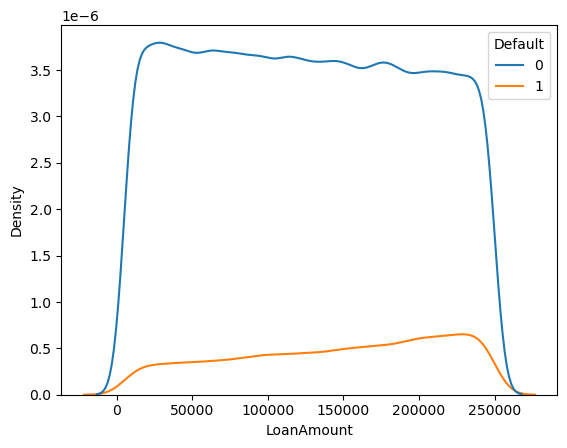

In [66]:
sns.kdeplot(data=df,x=df['LoanAmount'],hue='Default')

<Axes: xlabel='Default', ylabel='LoanAmount'>

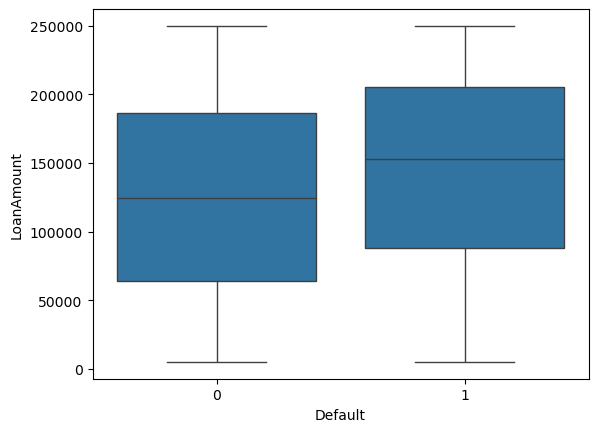

In [67]:
sns.boxplot(x=df['Default'],y=df['LoanAmount'])

In [68]:
# Observation (Loan Amount vs Default) : 
# Defaulters generally tend to have higher loan amounts compared to non-defaulters, suggesting that larger borrowing amounts may increase repayment risk.
# The distributions show noticeable separation with comparatively lower overlap, indicating that LoanAmount may act as a strong predictive feature in loan default prediction.

<Axes: xlabel='MonthsEmployed', ylabel='Density'>

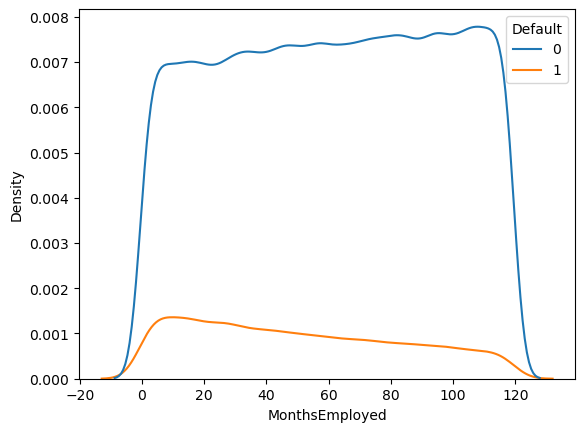

In [69]:
sns.kdeplot(data=df,x=df['MonthsEmployed'],hue='Default')

<Axes: xlabel='Default', ylabel='MonthsEmployed'>

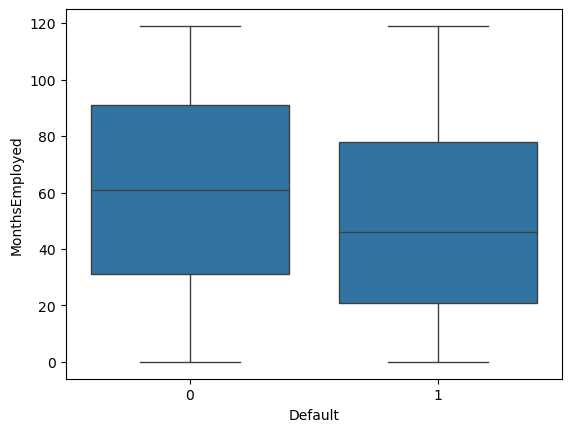

In [70]:
sns.boxplot(x=df['Default'],y=df['MonthsEmployed'])

In [71]:
# Observation (Months Employed vs Default) : 
# Defaulters generally tend to have lower employment duration compared to non-defaulters, indicating that lower job stability may contribute to higher default risk.
# The KDE distributions show clear separation with overlap occurring mainly at extreme values, suggesting that MonthsEmployed is a strong predictive feature for loan default prediction.

<Axes: xlabel='NumCreditLines', ylabel='Density'>

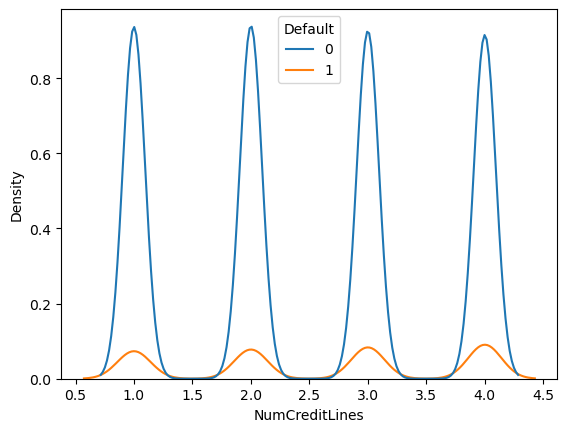

In [72]:
sns.kdeplot(data=df,x=df['NumCreditLines'],hue='Default')

<Axes: xlabel='Default', ylabel='NumCreditLines'>

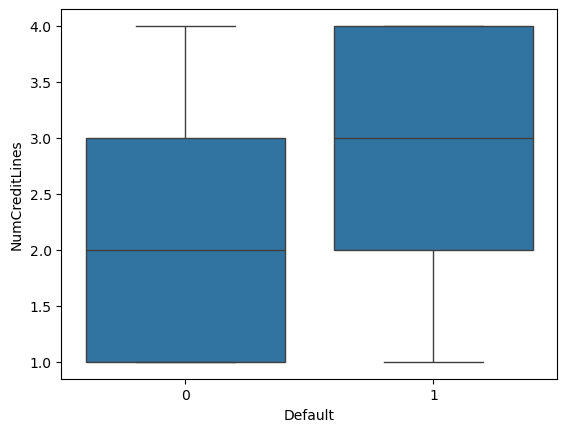

In [73]:
sns.boxplot(x=df['Default'],y=df['NumCreditLines'])

In [74]:
pd.crosstab(df['NumCreditLines'], df['Default'], normalize='index') * 100

Default,0,1
NumCreditLines,,
1,89.476666,10.523334
2,88.941213,11.058787
3,88.075320,11.924680
4,87.057607,12.942393


In [75]:
# Observation (Number of Credit Lines vs Default) : 
# The default percentage gradually increases as the number of credit lines increases. 
# Customers with more credit lines tend to show a slightly higher probability of default.
# Although a consistent trend is visible, the increase is relatively moderate, suggesting that NumCreditLines may provide moderate predictive information and can be more effective when combined with other financial features.

In [76]:
pd.crosstab(df['LoanTerm'], df['Default'], normalize='index') * 100

Default,0,1
LoanTerm,,
12,88.382362,11.617638
24,88.392245,11.607755
36,88.431484,11.568516
48,88.425908,11.574092
60,88.303945,11.696055


In [77]:
# Observation (Loan Term vs Default) : 
# LoanTerm does not show a significant difference in default percentage across different repayment durations. 
# The default rate remains nearly constant for all loan terms.
# This suggests that LoanTerm alone may have weak predictive power and its influence on default behavior may depend on interactions with other financial features.

## (7) Feature Engineering / Data Preprocessing

In [78]:
# Feature Selection Decision : 
# The LoanID feature was removed because it acts only as a unique identifier and does not contribute meaningful information for prediction.
# No additional features were removed at this stage because correlation analysis and EDA did not indicate strong multicollinearity or completely irrelevant variables. 
# Features with weak individual relationships may still contribute useful information when combined with other variables in machine learning models.

In [79]:
# Feature and Target Separation

X = df.iloc[:,0:-1]
y = df['Default']

In [80]:
# Feature and Target Separation : 
# The dataset is divided into input features (X) and the target variable (y). 
# The feature set contains all independent variables used for learning patterns, while the target variable contains the output to be predicted.
# Separating features and target variables ensures that preprocessing and transformations are applied only to input data and prevents unintended modifications to the prediction target.

In [81]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [82]:
# Observation (Train-Test Split) : 
# The dataset is divided into training and testing sets to evaluate model performance on unseen data. 
# The training set is used for learning patterns, while the testing set is used to assess generalization capability.
# An 80:20 split ratio is used, and stratification is applied to maintain the original class distribution in both datasets because the target variable is imbalanced.

In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_features = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines','InterestRate','LoanTerm','DTIRatio']
categorical_features = ['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

In [84]:
X_train_trf = preprocessor.fit_transform(X_train)
X_test_trf = preprocessor.transform(X_test)

In [85]:
# Encoding Strategy : 
# Categorical features need to be converted into numerical form because machine learning models cannot directly process categorical values.
# Ordinal encoding is applied to Education because it contains a meaningful order of levels, while one-hot encoding is used for nominal variables without natural ordering. 
# Binary variables are converted into numerical format using binary encoding.
# To avoid data leakage, encoders are fitted only on training data and then applied to the testing data.

In [86]:
# Decision on Class Imbalance Handling :
# Although the dataset shows some class imbalance, the imbalance is not extremely severe. 
# Instead of directly applying oversampling techniques, baseline models will first be trained on the original data.
# Model performance will then be evaluated, and imbalance handling techniques such as SMOTE may be considered if prediction performance for the minority class is unsatisfactory.

In [87]:
# Scaling Strategy :
# Feature scaling is applied for machine learning algorithms that are sensitive to feature magnitude and distance calculations. 
# Models such as Logistic Regression, KNN, and SVM can benefit from scaling because features with larger values may dominate the learning process.
# Tree-based models are generally less sensitive to scaling because they split data based on conditions rather than distances.
# To avoid data leakage, scaling is fitted only on the training data and then applied to the testing data. (Done with Encoding)

## (8) Model Training

In [88]:
# Model Selection :
# Multiple classification algorithms are selected to compare performance across different learning approaches and identify the most suitable model for loan default prediction.
# The selected models include Logistic Regression, KNN, Naive Bayes, Decision Tree, Random Forest, SVM, and XGBoost. 
# These models represent different categories such as linear models, distance-based methods, probabilistic techniques, tree-based algorithms, and ensemble learning methods.Using multiple algorithms enables performance comparison and helps determine which model captures the patterns and relationships within the dataset most effectively.

In [89]:
# Model Training Strategy : 
# The models will first be trained using default parameters to establish baseline performance. 
# Evaluation metrics will then be analyzed to understand each model's behavior and predictive capability.
# Cross-validation and hyperparameter tuning techniques may be applied to improve model performance and reduce the possibility of overfitting or underfitting.

In [90]:
# Logistic Regression : 
# Logistic Regression is used as a baseline model because it is computationally efficient, easy to interpret, and performs well for binary classification problems.
# It provides a simple reference point for model comparison and helps determine whether more complex algorithms offer meaningful performance improvements.

In [91]:
# Class Weight Selection : 
# Since the target variable is imbalanced, class weights are adjusted to give greater importance to the minority class during training.
# Using `class_weight='balanced' helps reduce prediction bias toward the majority class and can improve the model's ability to identify default cases.

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

lr = LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
lr.fit(X_train_trf,y_train)
y_train_pred = lr.predict(X_train_trf)
y_test_pred = lr.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
y_test_prob = lr.predict_proba(X_test_trf)[:,1]

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Training data accuracy :  0.6753330037155431
Testing data accuracy :  0.6763853534364598
Recall: 0.6990389479008599
F1 Score: 0.3340988758612353
ROC AUC: 0.753178399553392

Confusion Matrix
[[30397 14742]
 [ 1785  4146]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [93]:
# Logistic Regression Model Performance : 
# The Logistic Regression model achieved similar training and testing accuracy, indicating stable generalization without significant overfitting.
# The model achieved a recall of approximately 70%, meaning it successfully identified most default cases. 
# However, precision remained relatively low, indicating a high number of false positive predictions where non-defaulters were incorrectly classified as defaulters.
# The ROC-AUC score suggests moderate discriminatory capability, indicating that the model can reasonably distinguish between default and non-default customers.
# Overall, Logistic Regression provides a useful baseline model, but further improvement may be possible using more advanced algorithms.

In [94]:
# Business Interpretation : 
# For loan default prediction, recall is an important metric because failing to identify an actual defaulter can lead to financial losses.
# A higher recall reduces the number of false negatives and improves risk detection.
# However, precision should also be considered because excessive false positives may incorrectly classify reliable customers as risky. 
# Therefore, maintaining a balance between recall and precision is beneficial.

In [95]:
# KNN : 
# KNN is a distance-based classification algorithm that predicts class labels using nearby data points. Since features with larger values can dominate distance calculations, feature scaling is important.
# KNN can become computationally expensive for large datasets because distance calculations are performed for prediction against many neighboring samples.

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_trf,y_train)
y_train_pred = knn.predict(X_train_trf)
y_test_pred = knn.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
y_test_prob = knn.predict_proba(X_test_trf)[:,1]

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Training data accuracy :  0.89489271919991
Testing data accuracy :  0.8740356373604856
Recall: 0.0721632102512224
F1 Score: 0.11743723418850323
ROC AUC: 0.6141100681273356

Confusion Matrix
[[44209   930]
 [ 5503   428]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     45139
           1       0.32      0.07      0.12      5931

    accuracy                           0.87     51070
   macro avg       0.60      0.53      0.52     51070
weighted avg       0.82      0.87      0.84     51070



In [97]:
# KNN Model Performance : 
# The KNN model achieved relatively high accuracy; however, accuracy alone is not sufficient for evaluating imbalanced datasets.
# The recall score is very low, indicating that the model failed to identify a large proportion of actual default cases. Although precision improved compared to Logistic Regression, the model produced a high number of false negatives.
# The ROC-AUC score also remained lower than the Logistic Regression model, suggesting weaker class discrimination capability. Therefore, KNN may not be suitable for this loan default prediction problem in its baseline configuration.

In [98]:
# Naive Bayes : 
# Naive Bayes is a probabilistic classification algorithm that assumes features are conditionally independent of one another.
# Although complete feature independence is rarely true in real-world datasets, Naive Bayes can still perform effectively and provides a useful baseline for comparison.

In [99]:
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

nb = GaussianNB()
nb.fit(X_train_trf,y_train)
y_train_pred = nb.predict(X_train_trf)
y_test_pred = nb.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
y_test_prob = nb.predict_proba(X_test_trf)[:,1]

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Training data accuracy :  0.8847936870034316
Testing data accuracy :  0.8847464264734678
Recall: 0.05024447816557073
F1 Score: 0.09194692995988893
ROC AUC: 0.7455478806917581

Confusion Matrix
[[44886   253]
 [ 5633   298]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.54      0.05      0.09      5931

    accuracy                           0.88     51070
   macro avg       0.71      0.52      0.52     51070
weighted avg       0.85      0.88      0.84     51070



In [100]:
# Naive Bayes Model Performance : 
# The Naive Bayes model achieved stable training and testing accuracy, indicating good generalization performance without significant overfitting.
# However, the recall score was extremely low, meaning that the model failed to identify most default cases and produced a large number of false negatives. Although precision was relatively high, the model predicted only a small number of customers as defaulters.
# The ROC-AUC score remained moderate, suggesting reasonable probability ranking capability, but overall performance for default detection was weak. Therefore, Naive Bayes may not be suitable for this loan prediction problem in its baseline configuration.

In [101]:
# Decision Tree :
# Decision Tree is a rule-based classification algorithm that creates decision boundaries through feature splits.
# Feature scaling is generally not required because Decision Trees use conditional splitting instead of distance calculations.
# Decision Trees can easily overfit if allowed to grow excessively because they may memorize patterns and noise present in training data.

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_trf,y_train)
y_train_pred = dt.predict(X_train_trf)
y_test_pred = dt.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
y_test_prob = dt.predict_proba(X_test_trf)[:,1]

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Training data accuracy :  1.0
Testing data accuracy :  0.8016056393185823
Recall: 0.23132692631933907
F1 Score: 0.21310966138552345
ROC AUC: 0.5539319228065381

Confusion Matrix
[[39566  5573]
 [ 4559  1372]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45139
           1       0.20      0.23      0.21      5931

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.82      0.80      0.81     51070



In [103]:
# Decision Tree Model Performance : 
# The Decision Tree model achieved perfect training accuracy but significantly lower testing accuracy, indicating strong overfitting behavior. The model appears to memorize training patterns rather than generalize effectively to unseen data.
# Although recall improved compared to some previous models, the model still failed to identify many default cases. The ROC-AUC score remained relatively low, suggesting weak class discrimination ability.
# The baseline Decision Tree model may require hyperparameter tuning techniques such as controlling tree depth and minimum sample requirements to reduce overfitting and improve performance.

In [104]:
# Random Forest : 
# Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance and reduce overfitting.
# Each tree is trained using random samples and random feature selection, which increases diversity among trees. Final predictions are obtained through aggregation of individual tree predictions.
# Feature scaling is generally not required because Random Forest uses rule-based splitting rather than distance calculations.

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_trf,y_train)
y_train_pred = rf.predict(X_train_trf)
y_test_pred = rf.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
y_test_prob = rf.predict_proba(X_test_trf)[:,1]

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Training data accuracy :  0.9999706281177029
Testing data accuracy :  0.885275112590562
Recall: 0.028831562974203338
F1 Score: 0.055152394775036286
ROC AUC: 0.7332827557526842

Confusion Matrix
[[45040    99]
 [ 5760   171]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.63      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.76      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070



In [106]:
# Random Forest Model Performance : 
# The Random Forest model achieved very high training accuracy but noticeably lower testing accuracy, indicating some overfitting behavior.
# Although overall accuracy was high, the recall score remained extremely low, showing that the model failed to identify many actual default cases. The model produced a large number of false negatives, which is undesirable in loan default prediction.
# The ROC-AUC score suggests moderate class discrimination capability, but the baseline Random Forest model may require techniques such as class balancing and hyperparameter tuning to improve minority class detection.

In [107]:
# SVM : 
# Support Vector Machine (SVM) is a classification algorithm that attempts to find an optimal decision boundary with the maximum margin between classes.
# Feature scaling is important because SVM is sensitive to feature magnitudes.
# SVM can become computationally expensive for large datasets due to the complexity of finding the optimal separating boundary.

In [108]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

svm = LinearSVC(class_weight='balanced',random_state=42,max_iter=5000)
svm.fit(X_train_trf, y_train)
y_train_pred = svm.predict(X_train_trf)
y_test_pred = svm.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_test_pred))
print("\nClassification Report")
print(classification_report(y_test,y_test_pred))

Training data accuracy :  0.6735706907777185
Testing data accuracy :  0.6747405521832779
Recall: 0.7035912999494183
F1 Score: 0.3344151941339103

Confusion Matrix
[[30286 14853]
 [ 1758  4173]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.67      0.78     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.67      0.73     51070



In [109]:
# SVM Model Performance : 
# The SVM model achieved similar training and testing accuracy, indicating stable generalization performance without significant overfitting.
# The model achieved a high recall score and successfully identified a large proportion of default cases. However, precision remained relatively low, resulting in a large number of false positive predictions.
# Overall, SVM demonstrated strong ability in detecting risky customers and performed similarly to Logistic Regression in the baseline comparison.

In [110]:
# XGBoost : 
# XGBoost is a boosting-based ensemble algorithm where trees are built sequentially, and each new tree attempts to correct errors made by previous trees.
# It performs well on structured datasets because it can capture complex non-linear relationships, reduce overfitting through regularization, and iteratively improve prediction performance.

In [111]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_trf,y_train)
y_train_pred = xgb.predict(X_train_trf)
y_test_pred = xgb.predict(X_test_trf)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
y_test_prob = xgb.predict_proba(X_test_trf)[:,1]

print('Training data accuracy : ' , train_accuracy)
print('Testing data accuracy : ' , test_accuracy)
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))

Training data accuracy :  0.8937570064177562
Testing data accuracy :  0.885823379674956
Recall: 0.08379699881976058
F1 Score: 0.14564102564102563
ROC AUC: 0.7431500866640566

Confusion Matrix
[[44742   397]
 [ 5434   497]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.56      0.08      0.15      5931

    accuracy                           0.89     51070
   macro avg       0.72      0.54      0.54     51070
weighted avg       0.85      0.89      0.85     51070



In [112]:
# COMPARISON : 
#  Model                Recall     F1  ROC-AUC  Notes            

#  Logistic Regression    0.70  0.334    0.753  Strong recall    
#  Linear SVM             0.70  0.334        —  Similar to LR    
#  Decision Tree          0.22  0.207     0.55  Overfitting      
#  XGBoost                0.08  0.142    0.743  Weak recall      
#  KNN                   0.078  0.126     0.62  Weak recall      
#  Random Forest         0.032  0.061    0.737  Weak recall      
#  Naive Bayes           0.023  0.044    0.751  Very weak recall 

In [113]:
# Model Comparison Summary : 
# Multiple classification algorithms were trained and evaluated to identify the most suitable model for loan default prediction. Since the dataset is imbalanced and missing an actual defaulter can lead to financial risk, evaluation focused not only on accuracy but also on recall, F1-score, and ROC-AUC.
# Logistic Regression and SVM achieved the highest recall scores and successfully identified a large proportion of default cases. Although both models produced lower precision and more false positives, they demonstrated stronger ability in detecting risky customers.
# Tree-based and boosting models such as Decision Tree, Random Forest, and XGBoost achieved relatively high accuracy but struggled to identify default cases effectively, resulting in lower recall values. KNN and Naive Bayes also showed weaker performance for this problem.
# Based on baseline model comparison, Logistic Regression, SVM, and XGBoost were selected as the most promising candidates for further evaluation through cross-validation and hyperparameter tuning.

## (9) Cross Validation on Top Models

In [114]:
# Cross Validation : 
# A single train-test split may provide misleading performance because results can vary depending on how the data is divided. Cross-validation repeatedly trains and evaluates the model on different subsets of data and provides a more reliable estimate of model performance.
# Cross-validation helps evaluate model stability and reduces dependence on a single random split. It was applied only to selected top-performing models to avoid unnecessary computation on weaker models.

In [115]:
# Stratified K-Fold : 
# The dataset is imbalanced, so maintaining the original class distribution during splitting is important. Standard K-Fold may create folds with uneven class proportions, which can lead to unreliable evaluation results.
# Stratified K-Fold preserves approximately the same target class ratio in every fold, resulting in more stable and representative model evaluation.

In [116]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Logistic Regression
lr_cv = cross_val_score(lr,X_train_trf,y_train,cv=skf,scoring='recall')
print("Logistic Regression Recall CV Scores:", lr_cv)
print("Average Recall:", np.mean(lr_cv))

# Linear SVM
svm_cv = cross_val_score(svm,X_train_trf,y_train,cv=skf,scoring='recall')
print("\nSVM Recall CV Scores:", svm_cv)
print("Average Recall:", np.mean(svm_cv))

# XGBoost
xgb_cv = cross_val_score(xgb,X_train_trf,y_train,cv=skf,scoring='recall')
print("\nXGBoost Recall CV Scores:", xgb_cv)
print("Average Recall:", np.mean(xgb_cv))

Logistic Regression Recall CV Scores: [0.68598525 0.6971549  0.67685497 0.69203204 0.68844857]
Average Recall: 0.688095145862246

SVM Recall CV Scores: [0.68788198 0.69989463 0.67938449 0.69392917 0.69013491]
Average Recall: 0.6902450347130289

XGBoost Recall CV Scores: [0.08387777 0.08092729 0.08621417 0.08473862 0.07862563]
Average Recall: 0.0828766945591081


In [117]:
# Cross Validation Summary : 
# Cross-validation was performed using Stratified K-Fold with recall as the evaluation metric because identifying default customers is the primary objective.
# Logistic Regression and SVM achieved consistently high recall scores with very small variation across folds, indicating stable and reliable performance. Both models successfully maintained strong default detection capability across multiple subsets of data.
# XGBoost achieved significantly lower recall values and consistently underperformed in detecting default cases. Based on cross-validation results, Logistic Regression and SVM were selected as the strongest candidate models for further hyperparameter tuning.

In [118]:
# Hyperparameter Tuning : 
# Hyperparameter tuning is performed to improve model performance by finding the best parameter combination. Instead of manually selecting values, multiple parameter combinations are evaluated automatically.
# Since Logistic Regression and SVM showed strong and stable performance during model comparison and cross-validation, these models were selected for tuning.

In [119]:
# RandomizedSearchCV : 
# Hyperparameter tuning was performed using RandomizedSearchCV to identify the best parameter combination for improving model performance. Instead of testing every possible combination like GridSearchCV, RandomizedSearchCV evaluates a limited number of randomly selected parameter combinations.
# Since the dataset is large, RandomizedSearchCV was preferred because it reduces computational time while still providing effective optimization results. Recall was selected as the scoring metric because correctly identifying default customers is the primary objective of this project.

In [120]:
# Logistic Regression

from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
param_dist = {'C':[0.01,0.1,1,10,100],'class_weight':[None,'balanced'],'solver':['liblinear','lbfgs']}
random_lr = RandomizedSearchCV(estimator=LogisticRegression(random_state=42),param_distributions=param_dist,n_iter=10,scoring='recall',cv=skf,random_state=42,n_jobs=-1)
random_lr.fit(X_train_trf,y_train)

print("Best Parameters:",random_lr.best_params_)
print("Best Recall:",random_lr.best_score_)

Best Parameters: {'solver': 'lbfgs', 'class_weight': 'balanced', 'C': 0.01}
Best Recall: 0.688179436239798


In [121]:
# Logistic Regression Hyperparameter Tuning Results : 
# Hyperparameter tuning was performed using RandomizedSearchCV with recall as the evaluation metric. The best parameter combination selected a balanced class weight, stronger regularization, and the lbfgs solver.
# The tuned model produced only a very small improvement in recall compared to the baseline model, indicating that Logistic Regression was already performing near its optimal configuration for this dataset.

In [122]:
# SVM Hyperparameter Tuning : 
# Hyperparameter tuning was performed to improve SVM performance by selecting an optimal parameter combination. Parameters related to regularization and class imbalance handling were tuned because they can directly affect the model's ability to detect default customers.
# Recall was selected as the optimization metric because identifying risky customers is the primary objective of this project.

In [123]:
# SVM Hyperparameter Tuning Note : 
# Hyperparameter tuning for SVM was not performed extensively because of the large dataset size and high computational cost. Even after reducing the search space and optimization iterations, training time remained significantly high.
# Baseline evaluation and cross-validation results already showed strong and stable performance, indicating that SVM was performing effectively without substantial additional tuning. Therefore, the baseline SVM model was retained for further comparison and final model selection.

In [124]:
# Final Model Selection : 
# Based on model comparison, cross-validation, and hyperparameter tuning results, Logistic Regression was selected as the final model.
# Although both Logistic Regression and SVM achieved strong recall values, Logistic Regression was preferred because it demonstrated stable performance across cross-validation folds while requiring lower computational cost. Hyperparameter tuning also showed that the baseline model was already performing near its optimal configuration.
# In addition, Logistic Regression provides better interpretability because feature coefficients can be analyzed to understand how different variables influence loan default prediction.

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

final_model = LogisticRegression(C=0.01,class_weight='balanced',solver='lbfgs',random_state=42)
final_model.fit(X_train_trf, y_train)
y_pred = final_model.predict(X_test_trf)

print("Testing Accuracy:",accuracy_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report")
print(classification_report(y_test,y_pred))

Testing Accuracy: 0.6765224202075583
Recall: 0.6997133704265722
F1 Score: 0.33440773569701854
ROC AUC: 0.6865943178591134

Confusion Matrix
[[30400 14739]
 [ 1781  4150]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [126]:
# Final Model Evaluation : 
# The final Logistic Regression model was evaluated on unseen test data. The model achieved a recall of approximately 70%, indicating strong ability to identify potential loan defaulters, which is the primary objective of this project.
# Although the precision for the minority class is relatively low, this is acceptable in a risk-based problem where identifying as many defaulters as possible is more important than minimizing false positives.
# Overall, the model provides a balanced trade-off between recall and precision and is suitable for loan default prediction.

## (10) Save Final Model and Preprocessing Pipeline

In [127]:
# Saving Model and Preprocessing Pipeline : 
# The trained model and preprocessing pipeline are saved so they can be reused later without retraining. During deployment, new input data must go through the same preprocessing steps used during training before generating predictions.

In [128]:
import pickle
pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))
pickle.dump(final_model, open('loan_default_model.pkl', 'wb'))
print("Files saved successfully")

Files saved successfully


In [129]:
loaded_preprocessor = pickle.load(open('preprocessor.pkl','rb'))
loaded_model = pickle.load(open('loan_default_model.pkl','rb'))
print("Files loaded successfully")

Files loaded successfully


In [130]:
loaded_preprocessor = pickle.load(open('preprocessor.pkl','rb'))
loaded_model = pickle.load(open('loan_default_model.pkl','rb'))
print(type(loaded_model))
print(type(loaded_preprocessor))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


## (11) Prediction on New Customer Data

In [131]:
# Prediction on New Customer Data : 
# After training and saving the model, predictions can be made on new customer information. The same preprocessing pipeline used during training must also be applied to new input data before generating predictions.

In [132]:
import pandas as pd
import pickle
loaded_preprocessor = pickle.load(open('preprocessor.pkl','rb'))
loaded_model = pickle.load(open('loan_default_model.pkl','rb'))
new_customer = pd.DataFrame({'Age':[35],'Income':[45000],'LoanAmount':[15000],'CreditScore':[650],'MonthsEmployed':[60],'NumCreditLines':[4],'InterestRate':[10.0],'LoanTerm':[36],'DTIRatio':[0.35],'Education':["Bachelor's"],'EmploymentType':['Full-time'],'MaritalStatus':['Married'],'HasMortgage':['Yes'],'HasDependents':['Yes'],'LoanPurpose':['Home'],'HasCoSigner':['No']})
new_customer_trf = loaded_preprocessor.transform(new_customer)
prediction = loaded_model.predict(new_customer_trf)
if prediction[0] == 1:
    print("Customer likely to Default")
else:
    print("Customer likely Non-default")

Customer likely Non-default


In [133]:
# Project File Organization : 
# The project files were organized in a structured format to make deployment easier. Trained model files and preprocessing objects were stored separately so they can be directly loaded inside the application without retraining the model.
# Why Saved Models Are Used : 
# The model is not retrained during deployment. Instead, the previously saved model and preprocessing pipeline are loaded and used for prediction. This reduces computation time and improves application performance.

## FINAL MODEL

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pickle

df = pd.read_csv("Loan_default.csv")
df = df.drop(columns=['LoanID'])
X = df.drop('Default', axis=1)
y = df['Default']
numeric_features = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines','InterestRate','LoanTerm','DTIRatio']
categorical_features = ['Education','EmploymentType','MaritalStatus','HasMortgage','HasDependents','LoanPurpose','HasCoSigner']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
preprocessor = ColumnTransformer([('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
X_train_trf = preprocessor.fit_transform(X_train)
X_test_trf = preprocessor.transform(X_test)
model = LogisticRegression(C=0.01,class_weight='balanced',solver='lbfgs',random_state=42)
model.fit(X_train_trf, y_train)
y_pred = model.predict(X_test_trf)

print(classification_report(y_test, y_pred))

model = pickle.load(open("loan_default_model.pkl","rb"))
preprocessor = pickle.load(open("preprocessor.pkl","rb"))
print(model)
print(preprocessor)
pickle.dump(preprocessor, open("preprocessor.pkl", "wb"))
pickle.dump(model, open("loan_default_model.pkl", "wb"))

              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070

LogisticRegression(C=0.01, class_weight='balanced', random_state=42)
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Income', 'LoanAmount', 'CreditScore',
                                  'MonthsEmployed', 'NumCreditLines',
                                  'InterestRate', 'LoanTerm', 'DTIRatio']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Education', 'EmploymentType',
                                  'MaritalStatus', 'HasMortgage',
                                  'HasDependents', 'LoanPurpose',
                                  'HasCoSig